# Segmentation Debug Notebook

This notebook is independent from the main feature-extraction notebook.  
It is used only to inspect segmentation results visually.

Expected use:
1. Set the CSV and video paths and run segmentation.
2. Print detected phase boundaries.
3. Plot the segmentation signals.
4. Inspect the real video frame-by-frame with the skeleton overlay.


In [ ]:
# ============================================================
# Cell 1 — Read input files and run segmentation
# ============================================================

%matplotlib widget

from pathlib import Path
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent.resolve()

# Force Python to import helper.py and segmentation.py from PROJECT_ROOT
if str(PROJECT_ROOT) in sys.path:
    sys.path.remove(str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT))

# Clear old imports if they were loaded from the wrong folder before
for module_name in ["helper", "segmentation"]:
    if module_name in sys.modules:
        del sys.modules[module_name]

from helper import POINTS, get_xyv, read_fps_from_video
from segmentation import resolve_gait_segments, create_phase_dataframe

import helper
import segmentation

print("PROJECT_ROOT:", PROJECT_ROOT)
print("helper.py:", helper.__file__)
print("segmentation.py:", segmentation.__file__)

# ------------------------------------------------------------
# Input files
# ------------------------------------------------------------
CSV_PATH = PROJECT_ROOT / "examples" / "demo_skeleton_2d_pixels.csv"
VIDEO_PATH = PROJECT_ROOT / "examples" / "demo_video_blurred.mp4"

print("CSV exists:", CSV_PATH.exists())
print("Video exists:", VIDEO_PATH.exists())

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------
RUN_SIT_TO_STAND = True

MANUAL_LATERAL_START_FRAME = None
MANUAL_TURN_START_FRAME = None
MANUAL_TURN_END_FRAME = None
MANUAL_FRONTAL_END_FRAME = None

MANUAL_STS_START_FRAME = None
MANUAL_STS_END_FRAME = None

# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------
df = pd.read_csv(CSV_PATH)

if "Frame" not in df.columns:
    raise ValueError("The CSV must contain a column named 'Frame'.")

df = df.sort_values("Frame").reset_index(drop=True)

# ------------------------------------------------------------
# Read FPS
# ------------------------------------------------------------
try:
    FPS, video_frame_count = read_fps_from_video(str(VIDEO_PATH))
except Exception as e:
    print("Could not open video with OpenCV.")
    print("Reason:", e)
    print("Using manual FPS = 30.")
    FPS = 30
    video_frame_count = None

print("CSV loaded:", CSV_PATH)
print("Video loaded:", VIDEO_PATH)
print("CSV shape:", df.shape)
print("First frame:", int(df["Frame"].min()))
print("Last frame:", int(df["Frame"].max()))
print("FPS:", FPS)
print("Video frame count:", video_frame_count)

# ------------------------------------------------------------
# Run segmentation
# ------------------------------------------------------------
(
    segmentation_result,
    turn_debug_df,
    foot_motion_debug_df,
    sts_debug_df,
) = resolve_gait_segments(
    df=df,
    fps=FPS,
    manual_lateral_start_frame=MANUAL_LATERAL_START_FRAME,
    manual_turn_start_frame=MANUAL_TURN_START_FRAME,
    manual_turn_end_frame=MANUAL_TURN_END_FRAME,
    manual_frontal_end_frame=MANUAL_FRONTAL_END_FRAME,
    run_sit_to_stand=RUN_SIT_TO_STAND,
    manual_sts_start_frame=MANUAL_STS_START_FRAME,
    manual_sts_end_frame=MANUAL_STS_END_FRAME,
)

phase_df = create_phase_dataframe(df, segmentation_result)

print("Segmentation completed.")

In [ ]:
# ============================================================
# Cell 2 — Print detected phase values
# ============================================================

print("Detected phase boundaries")
print("-------------------------")
print(f"Sit-to-stand: {segmentation_result['sit_to_stand_start']} → {segmentation_result['sit_to_stand_end']}")
print(f"Lateral walking: {segmentation_result['lateral_start']} → {segmentation_result['lateral_end']}")
print(f"Turning: {segmentation_result['turn_start']} → {segmentation_result['turn_end']}")
print(f"Frontal walking: {segmentation_result['frontal_start']} → {segmentation_result['frontal_end']}")
print()
print(f"Walking start: {segmentation_result['walking_start_frame']}")
print(f"Walking stop: {segmentation_result['walking_stop_frame']}")
print(f"Transition peak: {segmentation_result['transition_frame_peak']}")
print(f"Cornering time: {segmentation_result['cornering_time_sec']:.3f} s")

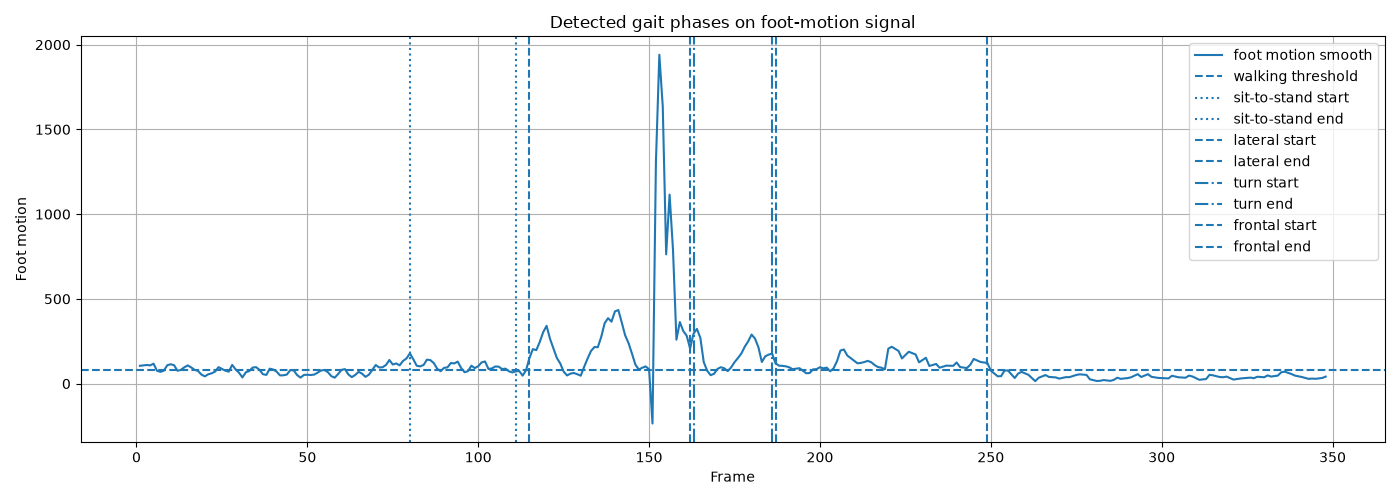

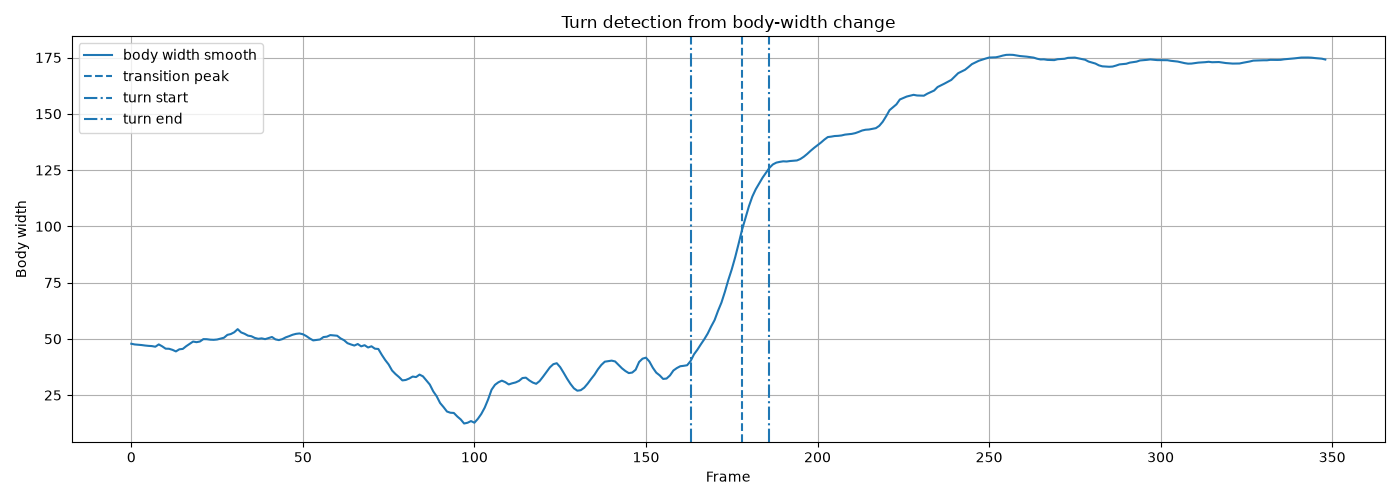

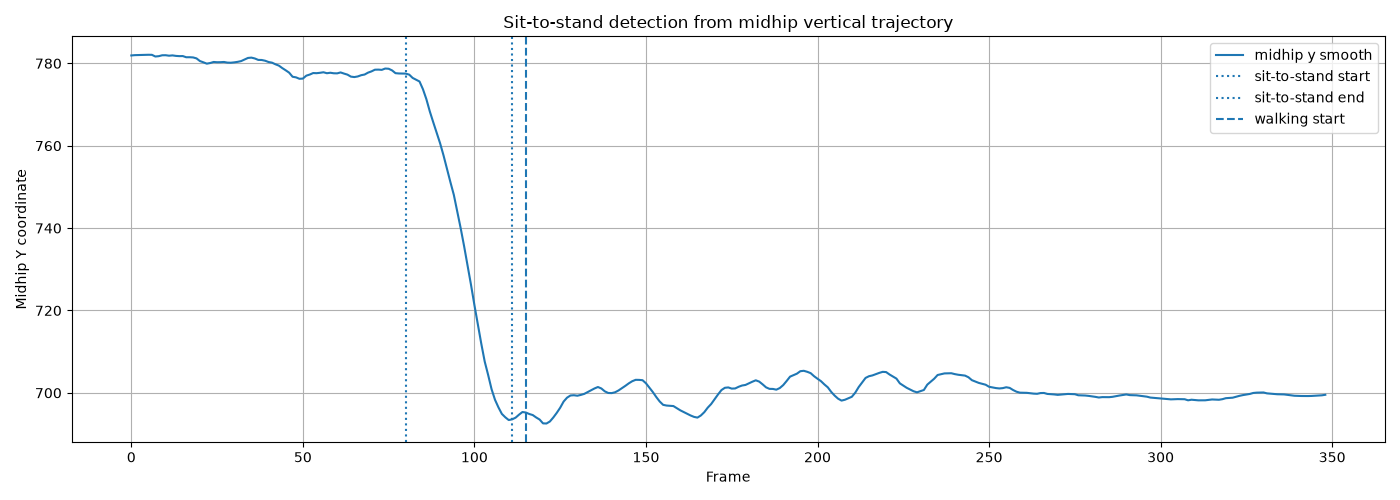

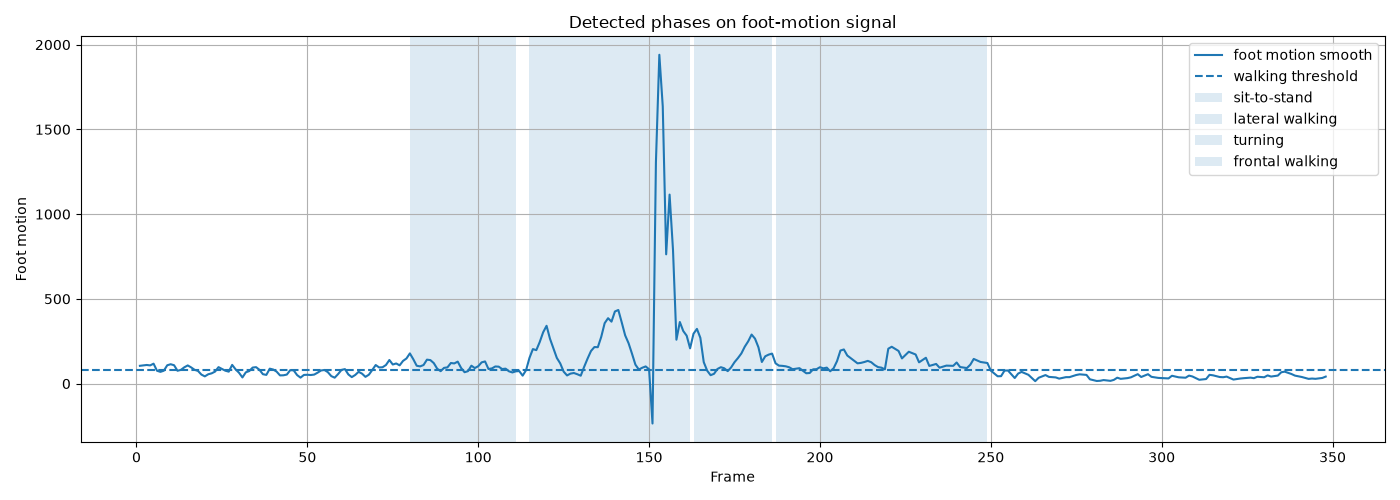

In [11]:
# ============================================================
# Cell 3 — Plot segmentation debug signals
# ============================================================

# ------------------------------------------------------------
# Plot walking/phase boundaries on foot-motion signal
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    foot_motion_debug_df["Frame"],
    foot_motion_debug_df["foot_motion_smooth"],
    label="foot motion smooth",
)

if "low_threshold" in foot_motion_debug_df.columns:
    plt.axhline(
        foot_motion_debug_df["low_threshold"].iloc[0],
        linestyle="--",
        label="walking threshold",
    )

# Sit-to-stand boundaries
if segmentation_result["sit_to_stand_start"] is not None:
    plt.axvline(
        segmentation_result["sit_to_stand_start"],
        linestyle=":",
        label="sit-to-stand start",
    )
    plt.axvline(
        segmentation_result["sit_to_stand_end"],
        linestyle=":",
        label="sit-to-stand end",
    )

# Walking/turning boundaries
plt.axvline(segmentation_result["lateral_start"], linestyle="--", label="lateral start")
plt.axvline(segmentation_result["lateral_end"], linestyle="--", label="lateral end")
plt.axvline(segmentation_result["turn_start"], linestyle="-.", label="turn start")
plt.axvline(segmentation_result["turn_end"], linestyle="-.", label="turn end")
plt.axvline(segmentation_result["frontal_start"], linestyle="--", label="frontal start")
plt.axvline(segmentation_result["frontal_end"], linestyle="--", label="frontal end")

plt.title("Detected gait phases on foot-motion signal")
plt.xlabel("Frame")
plt.ylabel("Foot motion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot turn detection signal
# ------------------------------------------------------------
plt.figure(figsize=(14, 5))

plt.plot(
    turn_debug_df["Frame"],
    turn_debug_df["body_width_smooth"],
    label="body width smooth",
)

plt.axvline(segmentation_result["transition_frame_peak"], linestyle="--", label="transition peak")
plt.axvline(segmentation_result["turn_start"], linestyle="-.", label="turn start")
plt.axvline(segmentation_result["turn_end"], linestyle="-.", label="turn end")

plt.title("Turn detection from body-width change")
plt.xlabel("Frame")
plt.ylabel("Body width")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Plot sit-to-stand detection signal
# ------------------------------------------------------------
if sts_debug_df is not None:
    plt.figure(figsize=(14, 5))

    plt.plot(
        sts_debug_df["Frame"],
        sts_debug_df["midhip_y_smooth"],
        label="midhip y smooth",
    )

    plt.axvline(
        segmentation_result["sit_to_stand_start"],
        linestyle=":",
        label="sit-to-stand start",
    )

    plt.axvline(
        segmentation_result["sit_to_stand_end"],
        linestyle=":",
        label="sit-to-stand end",
    )

    plt.axvline(
        segmentation_result["walking_start_frame"],
        linestyle="--",
        label="walking start",
    )

    plt.title("Sit-to-stand detection from midhip vertical trajectory")
    plt.xlabel("Frame")
    plt.ylabel("Midhip Y coordinate")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Sit-to-stand detection was not run.")



# ------------------------------------------------------------
# Visual validation of automatic gait-phase segmentation
# ------------------------------------------------------------


plt.figure(figsize=(14, 5))

plt.plot(
    foot_motion_debug_df["Frame"],
    foot_motion_debug_df["foot_motion_smooth"],
    label="foot motion smooth",
)

plt.axhline(
    foot_motion_debug_df["low_threshold"].iloc[0],
    linestyle="--",
    label="walking threshold",
)

plt.axvspan(
    segmentation_result["sit_to_stand_start"],
    segmentation_result["sit_to_stand_end"],
    alpha=0.15,
    label="sit-to-stand",
)

plt.axvspan(
    segmentation_result["lateral_start"],
    segmentation_result["lateral_end"],
    alpha=0.15,
    label="lateral walking",
)

plt.axvspan(
    segmentation_result["turn_start"],
    segmentation_result["turn_end"],
    alpha=0.15,
    label="turning",
)

plt.axvspan(
    segmentation_result["frontal_start"],
    segmentation_result["frontal_end"],
    alpha=0.15,
    label="frontal walking",
)

plt.title("Detected phases on foot-motion signal")
plt.xlabel("Frame")
plt.ylabel("Foot motion")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


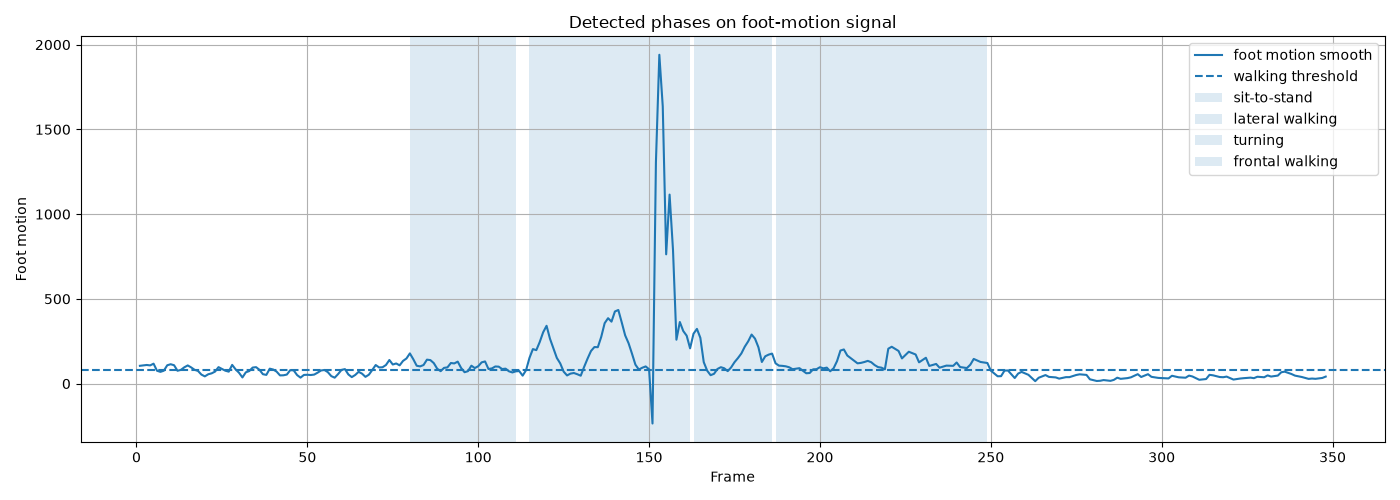

In [ ]:
# ============================================================
# Cell 4 — Smooth video viewer with skeleton overlay
# ============================================================

import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import display

SKELETON_EDGES = [
    ("left_shoulder", "right_shoulder"),
    ("left_shoulder", "left_hip"),
    ("right_shoulder", "right_hip"),
    ("left_hip", "right_hip"),

    ("left_hip", "left_knee"),
    ("left_knee", "left_ankle"),
    ("left_ankle", "left_heel"),
    ("left_heel", "left_foot_index"),

    ("right_hip", "right_knee"),
    ("right_knee", "right_ankle"),
    ("right_ankle", "right_heel"),
    ("right_heel", "right_foot_index"),
]


def get_phase_for_frame(frame):
    row = phase_df[phase_df["Frame"] == frame]

    if len(row) == 0:
        return "outside"

    return row["phase"].iloc[0]


def draw_skeleton_cv2(image, row, visibility_threshold=0.5):
    h, w = image.shape[:2]
    points_xy = {}

    for key, point in POINTS.items():
        x_col = f"{point}_x"
        y_col = f"{point}_y"
        v_col = f"{point}_vis"

        if x_col not in row.index or y_col not in row.index or v_col not in row.index:
            continue

        x = row[x_col]
        y = row[y_col]
        v = row[v_col]

        if not np.isfinite(x) or not np.isfinite(y) or not np.isfinite(v):
            continue

        if v < visibility_threshold:
            continue

        # Convert normalized coordinates to pixels if needed
        if 0 <= x <= 1 and 0 <= y <= 1:
            x = x * w
            y = y * h

        points_xy[key] = (int(x), int(y))

    for p1, p2 in SKELETON_EDGES:
        if p1 in points_xy and p2 in points_xy:
            cv2.line(image, points_xy[p1], points_xy[p2], (0, 255, 0), 2)

    for x, y in points_xy.values():
        cv2.circle(image, (x, y), 4, (255, 0, 0), -1)

    return image


cap = cv2.VideoCapture(str(VIDEO_PATH))

if not cap.isOpened():
    raise ValueError(f"Could not open video: {VIDEO_PATH}")


image_widget = widgets.Image(
    format="jpeg",
    width=800,
)

frame_label = widgets.HTML()

row_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(df) - 1,
    step=1,
    description="CSV row",
    continuous_update=False,
)

play = widgets.Play(
    value=0,
    min=0,
    max=len(df) - 1,
    step=1,
    interval=120,   # lower = faster playback
    description="Play",
    disabled=False,
)

widgets.jslink((play, "value"), (row_slider, "value"))

prev_button = widgets.Button(description="Previous")
next_button = widgets.Button(description="Next")


def make_frame(row_index):
    row_index = int(row_index)

    row = df.iloc[row_index]
    frame_number = int(row["Frame"])
    phase = get_phase_for_frame(frame_number)

    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    ok, frame_bgr = cap.read()

    if not ok:
        return None, f"Could not read video frame {frame_number}"

    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    # Resize for smoother display
    display_width = 800
    h, w = frame_rgb.shape[:2]
    scale = display_width / w
    display_height = int(h * scale)

    frame_rgb = cv2.resize(
        frame_rgb,
        (display_width, display_height),
        interpolation=cv2.INTER_AREA,
    )

    # Scale skeleton coordinates if they are pixel coordinates
    row_scaled = row.copy()

    for point in POINTS.values():
        x_col = f"{point}_x"
        y_col = f"{point}_y"

        if x_col in row_scaled.index and y_col in row_scaled.index:
            x = row_scaled[x_col]
            y = row_scaled[y_col]

            if np.isfinite(x) and np.isfinite(y):
                if not (0 <= x <= 1 and 0 <= y <= 1):
                    row_scaled[x_col] = x * scale
                    row_scaled[y_col] = y * scale

    frame_rgb = draw_skeleton_cv2(frame_rgb, row_scaled)

    text = f"CSV row: {row_index} | Video frame: {frame_number} | Phase: {phase}"

    cv2.putText(
        frame_rgb,
        text,
        (20, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )

    frame_bgr_out = cv2.cvtColor(frame_rgb, cv2.COLOR_RGB2BGR)
    ok, encoded = cv2.imencode(".jpg", frame_bgr_out)

    if not ok:
        return None, "Could not encode frame."

    return encoded.tobytes(), text


def update_view(change=None):
    image_bytes, text = make_frame(row_slider.value)

    frame_label.value = f"<b>{text}</b>"

    if image_bytes is not None:
        image_widget.value = image_bytes


def go_previous(_):
    row_slider.value = max(row_slider.min, row_slider.value - 1)


def go_next(_):
    row_slider.value = min(row_slider.max, row_slider.value + 1)


prev_button.on_click(go_previous)
next_button.on_click(go_next)
row_slider.observe(update_view, names="value")

controls = widgets.VBox([
    widgets.HBox([play, prev_button, next_button]),
    row_slider,
    frame_label,
])

display(controls)
display(image_widget)

update_view()